# Approximating $\sin(x)$

We will fit a cubic polynomial, $y = a + bx + cx^2 + dx^3$, to samples of $\sin(x)$. The model is deliberately small enough that we can write every gradient ourselves.


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

np.random.seed(42)


In [2]:
x = np.linspace(-math.pi, math.pi, 2000)
x

array([-3.14159265, -3.13844949, -3.13530633, ...,  3.13530633,
        3.13844949,  3.14159265], shape=(2000,))

In [3]:
y = np.sin(x)
y

array([-1.22464680e-16, -3.14315906e-03, -6.28628707e-03, ...,
        6.28628707e-03,  3.14315906e-03,  1.22464680e-16], shape=(2000,))

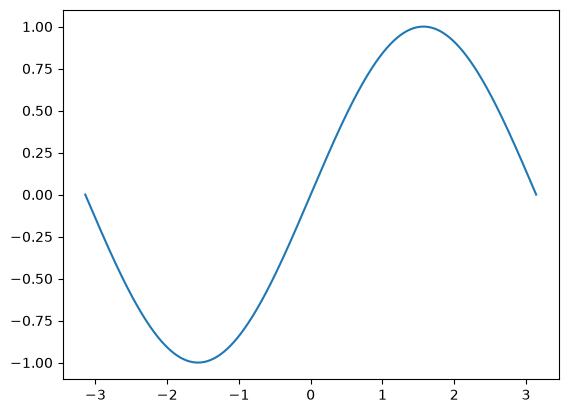

In [4]:
plt.plot(x, y)
plt.show()

# Writing the loss

We start from random coefficients and measure error with the sum of squared differences between the polynomial and the sine curve. Gradient descent will adjust the four coefficients to reduce that loss.


In [5]:
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()
a, b, c, d

(0.4967141530112327,
 -0.13826430117118466,
 0.6476885381006925,
 1.5230298564080254)

In [6]:
lr = 1e-6
lr

1e-06

# Backprop by hand

The derivative of the squared-error loss with respect to each prediction is `2 * (y_pred - y)`. The chain rule then tells us how much each coefficient contributed to that error, giving one gradient per parameter.


In [7]:
loss_history = []
snapshots = {}
param_history = []
checkpoints = {0, 10, 50, 200, 700, 1999}

param_history.append((a, b, c, d))

for t in range(2000):
    y_pred = a + b * x + c * x ** 2 + d * x ** 3
    loss = np.square(y_pred - y).sum()

    loss_history.append(loss)
    
    if t%100 == 0:
        print(t, loss)
        
    if t in checkpoints:
        snapshots[t] = y_pred.copy()

    grad_y_pred = 2 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()
    
    a -= lr * grad_a
    b -= lr * grad_b
    c -= lr * grad_c
    d -= lr * grad_d

    param_history.append((a, b, c, d))

0 621855.3996266082
100 1101.3506922035047
200 735.3370892976621
300 492.1176974808293
400 330.4442041786929
500 222.93987746235382
600 151.42965929466956
700 103.84420475255051
800 72.16650742423552
900 51.06973891882201
1000 37.01343029368128
1100 27.64363544019418
1200 21.39474179871964
1300 17.22507273740537
1400 14.441279783689994
1500 12.581673673512338
1600 11.338688994904889
1700 10.507339357332231
1800 9.950939069082132
1900 9.578299097982114


In [8]:
print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')

Result: y = 0.011773687408810535 + 0.8375511313685622 x + -0.002031156993023952 x^2 + -0.09060081965601073 x^3


# Watching gradient descent

The loss curve shows whether optimization is converging, while snapshots show what that progress means in the model's output space. The parameter traces show the corresponding path taken by $a$, $b$, $c$, and $d$.


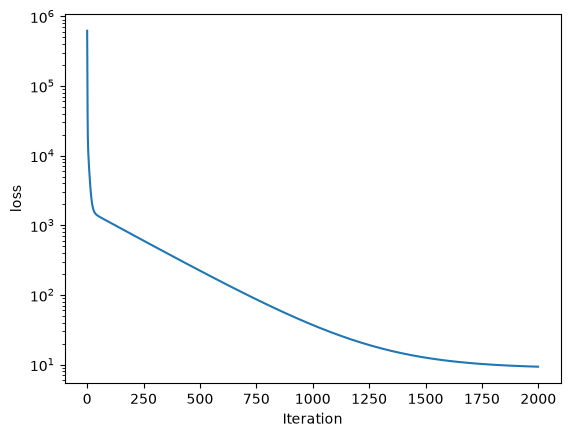

In [9]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("loss")
plt.yscale("log")
plt.show()

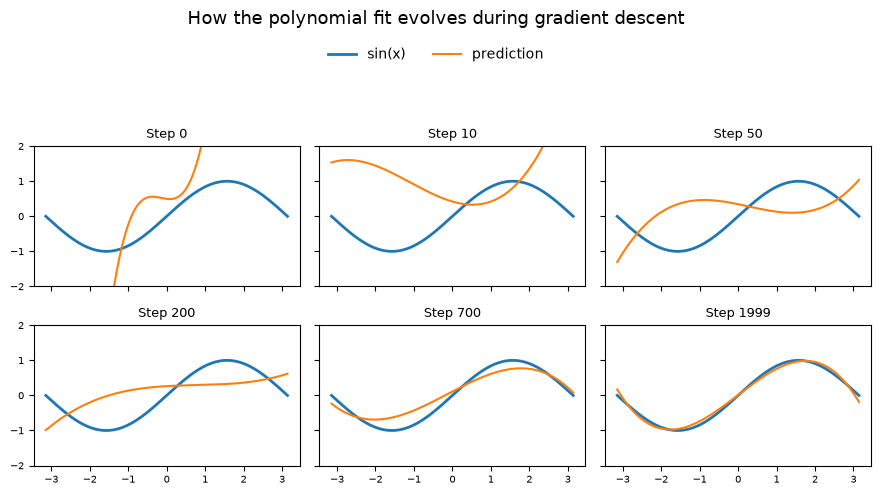

In [10]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(9, 5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (t, y_pred_snapshot) in zip(axes, snapshots.items()):
    ax.plot(x, y, label="sin(x)", linewidth=2)
    ax.plot(x, y_pred_snapshot, label="prediction")

    ax.set_title(f"Step {t}", fontsize=9)
    ax.set_ylim(-2, 2)
    ax.tick_params(labelsize=7)

# Main title
fig.suptitle(
    "How the polynomial fit evolves during gradient descent",
    fontsize=13,
    y=0.98
)

# Shared legend below title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=2,
    frameon=False
)

# Leave space at top for title + legend
plt.tight_layout(rect=[0, 0, 1, 0.84])

plt.show()

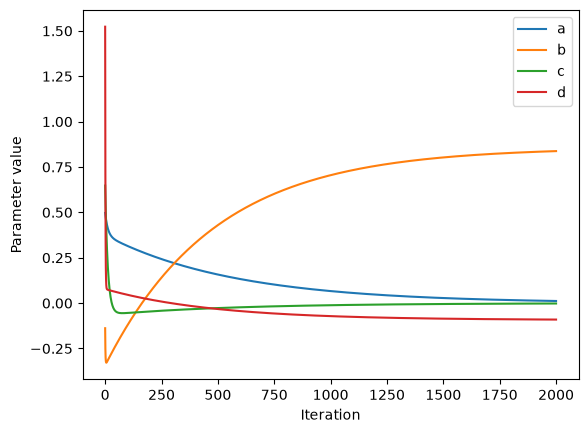

In [11]:
params = np.array(param_history)

plt.plot(params[:, 0], label="a")
plt.plot(params[:, 1], label="b")
plt.plot(params[:, 2], label="c")
plt.plot(params[:, 3], label="d")

plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.legend()
plt.show()

## Making the loss landscape visible

Our real model has four parameters, so its loss surface is four-dimensional. To see what gradient descent is actually doing, we'll temporarily keep only one parameter.


In [12]:
b = 2.0
lr = 1e-5
tol = 1e-2

b_history = []

for t in range(100):
    y_pred = b * x
    loss = np.square(y_pred - y).sum()

    b_history.append(b)

    grad_y_pred = 2 * (y_pred - y)
    grad_b = (grad_y_pred * x).sum()

    # How far would the next update move b?
    step = lr * grad_b

    if abs(step) < tol:
        break

    b -= lr * grad_b

In [13]:
b_values = np.linspace(-2, 3, 300)

loss_values = []

for candidate_b in b_values:
    candidate_pred = candidate_b * x
    candidate_loss = np.square(candidate_pred - y).sum()
    loss_values.append(candidate_loss)

In [14]:
print("Iterations:", len(b_history))
print("Final b:", b)
print("Final step:", abs(lr * grad_b))

Iterations: 23
Final b: 0.3793649244291343
Final step: 0.009992403348742428


In [15]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(b_values, loss_values)

dot, = ax.plot([], [], "o", markersize=8)

ax.set_xlabel("b")
ax.set_ylabel("Loss")
ax.set_title("Gradient descent finding the minimum")

def update(frame):
    b = b_history[frame]

    y_pred = b * x
    loss = np.square(y_pred - y).sum()

    dot.set_data([b], [loss])

    return dot,

animation = FuncAnimation(
    fig,
    update,
    frames=len(b_history),
    interval=100,
    repeat=False
)

plt.close()

HTML(animation.to_jshtml())

# The same thing in PyTorch

Now we repeat the manual calculation with PyTorch tensors. We are still deriving and applying the gradients ourselves—autograd has not entered the picture yet.


In [16]:
import torch

torch.manual_seed(42)


In [17]:
device = torch.device("cpu")
dtype = torch.float

In [18]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)
x, y

(tensor([-3.1416, -3.1384, -3.1353,  ...,  3.1353,  3.1384,  3.1416]),
 tensor([ 8.7423e-08, -3.1430e-03, -6.2863e-03,  ...,  6.2863e-03,
          3.1430e-03, -8.7423e-08]))

In [19]:
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)
a, b, c, d

(tensor(0.3367), tensor(0.1288), tensor(0.2345), tensor(0.2303))

In [20]:
lr = 1e-6

for t in range(2000):
    y_pred = a + b * x + c * x ** 2 + d * x ** 3
    loss = (y_pred - y).pow(2).sum().item()

    y_pred_grad = 2 * (y_pred - y)
    a_grad = y_pred_grad.sum()
    b_grad = (x * y_pred_grad).sum()
    c_grad = (x ** 2 * y_pred_grad).sum()
    d_grad = (x ** 3 * y_pred_grad).sum()

    if t % 100 == 0:
        print(t, loss, a_grad, b_grad, c_grad, d_grad)

    a -= lr * a_grad
    b -= lr * b_grad
    c -= lr * c_grad
    d -= lr * d_grad


0 17376.455078125 tensor(4435.2495) tensor(15683.9180) tensor(22742.6875) tensor(121504.2500)
100 461.9692077636719 tensor(418.9659) tensor(-1274.4799) tensor(-66.8688) tensor(181.2836)
200 310.8812561035156 tensor(351.6812) tensor(-1036.3726) tensor(-60.6700) tensor(147.4149)
300 210.26773071289062 tensor(295.8419) tensor(-842.7501) tensor(-51.0375) tensor(119.8747)
400 143.23683166503906 tensor(248.8688) tensor(-685.3016) tensor(-42.9336) tensor(97.4765)
500 98.55887603759766 tensor(209.3538) tensor(-557.2687) tensor(-36.1171) tensor(79.2673)
600 68.76502990722656 tensor(176.1131) tensor(-453.1558) tensor(-30.3827) tensor(64.4561)
700 48.886714935302734 tensor(148.1502) tensor(-368.4944) tensor(-25.5584) tensor(52.4131)
800 35.616764068603516 tensor(124.6272) tensor(-299.6492) tensor(-21.5008) tensor(42.6257)
900 26.753145217895508 tensor(104.8392) tensor(-243.6661) tensor(-18.0862) tensor(34.6610)
1000 20.829376220703125 tensor(88.1931) tensor(-198.1433) tensor(-15.2150) tensor(28.1

In [21]:
print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

Result: y = 0.009059897623956203 + 0.8446162343025208 x + -0.0015629850095137954 x^2 + -0.0916057676076889 x^3


# What does the learning rate do?

The learning rate scales every parameter update. A useful value makes steady progress; a value that is too large can repeatedly overshoot the minimum.


# When gradients explode

With an overly large learning rate, a large update can worsen the prediction, which creates a larger error, a larger gradient, and an even larger next update.

Here, “exploding gradients” describes runaway optimization from the step size. It is related to, but not identical to, gradients that grow while backpropagating through many layers in a deep network.


In [22]:
def train(lr, seed=42):
    torch.manual_seed(seed)
    a = torch.randn(())
    b = torch.randn(())
    c = torch.randn(())
    d = torch.randn(())

    losses = []
    grad_norms = []

    for t in range(2000):
        y_pred = a + b*x + c*x**2 + d*x**3
        loss = (y_pred - y).pow(2).sum()

        y_pred_grad = 2 * (y_pred - y)

        a_grad = y_pred_grad.sum()
        b_grad = (y_pred_grad * x).sum()
        c_grad = (y_pred_grad * x**2).sum()
        d_grad = (y_pred_grad * x**3).sum()

        grad_norm = torch.sqrt(
            a_grad**2 +
            b_grad**2 +
            c_grad**2 +
            d_grad**2
        )

        if not torch.isfinite(loss) or not torch.isfinite(grad_norm):
            break

        losses.append(loss.item())
        grad_norms.append(grad_norm.item())

        a -= lr * a_grad
        b -= lr * b_grad
        c -= lr * c_grad
        d -= lr * d_grad

    return losses, grad_norms


In [23]:
good_loss, good_grad = train(1e-6)
bad_loss, bad_grad = train(1e-5)

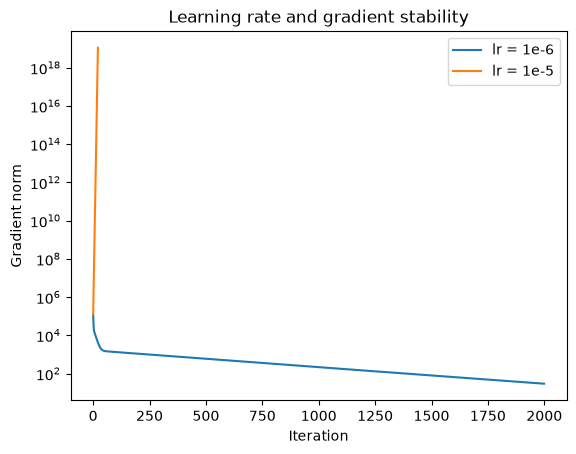

In [24]:
plt.plot(good_grad, label="lr = 1e-6")
plt.plot(bad_grad, label="lr = 1e-5")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Gradient norm")
plt.title("Learning rate and gradient stability")
plt.legend()

plt.show()

# NumPy vs PyTorch

The implementations look surprisingly similar, but the hardware does not do the same work. We will time NumPy on the CPU, then PyTorch on both the CPU and Apple's MPS GPU backend.

For this scaling experiment, we divide each gradient by the number of data points. Increasing `N` therefore changes the computational workload without also making each optimization update larger.


In [25]:
import time
import numpy as np
import torch

In [26]:
def train_numpy(x, y, steps=2000, lr=1e-6):
    a, b, c, d = [np.float32(v) for v in [0.5, -0.3, 0.2, 0.1]]

    for _ in range(steps):
        y_pred = a + b*x + c*x**2 + d*x**3

        grad_y_pred = 2 * (y_pred - y) / x.size

        grad_a = grad_y_pred.sum()
        grad_b = (grad_y_pred * x).sum()
        grad_c = (grad_y_pred * x**2).sum()
        grad_d = (grad_y_pred * x**3).sum()

        a -= lr * grad_a
        b -= lr * grad_b
        c -= lr * grad_c
        d -= lr * grad_d

In [27]:
def train_torch(x, y, steps=2000, lr=1e-6):
    device = x.device
    
    a, b, c, d = [torch.tensor(v, device=device) for v in [0.5, -0.3, 0.2, 0.1]]

    for _ in range(steps):
        y_pred = a + b*x + c*x**2 + d*x**3

        grad_y_pred = 2 * (y_pred - y) / x.numel()

        grad_a = grad_y_pred.sum()
        grad_b = (grad_y_pred * x).sum()
        grad_c = (grad_y_pred * x**2).sum()
        grad_d = (grad_y_pred * x**3).sum()

        a -= lr * grad_a
        b -= lr * grad_b
        c -= lr * grad_c
        d -= lr * grad_d

In [28]:
N = 2000

x_np = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
y_np = np.sin(x_np)

x_torch = torch.from_numpy(x_np)
y_torch = torch.from_numpy(y_np)

x_cpu = x_torch
y_cpu = y_torch

x_mps = x_torch.to("mps")
y_mps = y_torch.to("mps")

In [29]:
def benchmark(fn, *args, repeats=5, mps=False):
    times = []

    for _ in range(repeats):
        if mps:
            torch.mps.synchronize()

        start = time.perf_counter()

        fn(*args)

        if mps:
            torch.mps.synchronize()

        times.append(time.perf_counter() - start)

    return np.mean(times), np.std(times)


np_mean, np_std = benchmark(train_numpy, x_np, y_np)
torch_cpu_mean, torch_cpu_std = benchmark(train_torch, x_torch, y_torch)
torch_mps_mean, torch_mps_std = benchmark(train_torch, x_mps, y_mps, mps=True)

print(f"NumPy:   {np_mean * 1000:.2f} ± {np_std * 1000:.2f} ms")
print(f"PyTorch: {torch_cpu_mean * 1000:.2f} ± {torch_cpu_std * 1000:.2f} ms")
print(f"PyTorch MPS: {torch_mps_mean * 1000:.2f} ± {torch_mps_std * 1000:.2f} ms")

NumPy:   98.45 ± 12.09 ms
PyTorch: 98.40 ± 12.48 ms
PyTorch MPS: 767.27 ± 294.15 ms


In [30]:
sizes = [2_000, 20_000, 200_000]

results = {
    "numpy": [],
    "torch_cpu": [],
    "torch_mps": [],
}

for n in sizes:
    print(f"\nN = {n:,}")

    # Same float32 data for everyone
    x_np = np.linspace(-np.pi, np.pi, n, dtype=np.float32)
    y_np = np.sin(x_np)

    x_cpu = torch.from_numpy(x_np)
    y_cpu = torch.from_numpy(y_np)

    x_mps = x_cpu.to("mps")
    y_mps = y_cpu.to("mps")

    # Warm up MPS
    train_torch(x_mps, y_mps, steps=10)
    torch.mps.synchronize()

    np_mean, np_std = benchmark(
        train_numpy, x_np, y_np
    )

    cpu_mean, cpu_std = benchmark(
        train_torch, x_cpu, y_cpu
    )

    mps_mean, mps_std = benchmark(
        train_torch, x_mps, y_mps,
        mps=True
    )

    results["numpy"].append(np_mean)
    results["torch_cpu"].append(cpu_mean)
    results["torch_mps"].append(mps_mean)

    print(f"NumPy:       {np_mean * 1000:8.2f} ± {np_std * 1000:.2f} ms")
    print(f"PyTorch CPU: {cpu_mean * 1000:8.2f} ± {cpu_std * 1000:.2f} ms")
    print(f"PyTorch MPS: {mps_mean * 1000:8.2f} ± {mps_std * 1000:.2f} ms")


N = 2,000


NumPy:          92.66 ± 10.67 ms
PyTorch CPU:    97.33 ± 9.16 ms
PyTorch MPS:   618.43 ± 54.73 ms

N = 20,000


NumPy:         889.41 ± 182.58 ms
PyTorch CPU:   343.60 ± 94.77 ms
PyTorch MPS:   697.37 ± 135.16 ms

N = 200,000


NumPy:        5716.10 ± 617.58 ms
PyTorch CPU:  1337.80 ± 311.71 ms
PyTorch MPS:   964.05 ± 109.03 ms


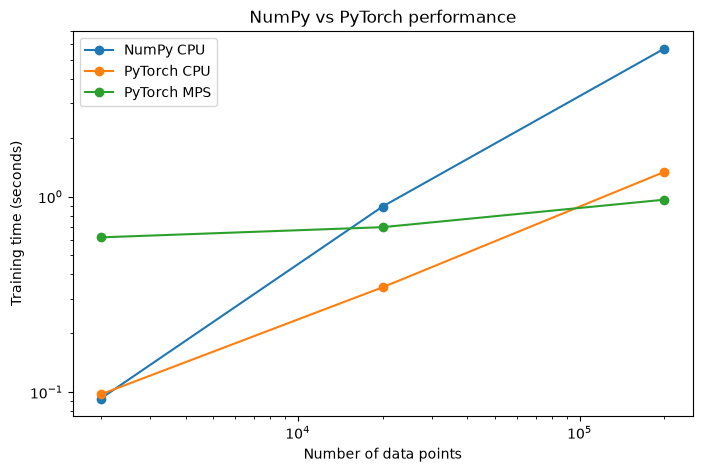

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(sizes, results["numpy"], marker="o", label="NumPy CPU")
plt.plot(sizes, results["torch_cpu"], marker="o", label="PyTorch CPU")
plt.plot(sizes, results["torch_mps"], marker="o", label="PyTorch MPS")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of data points")
plt.ylabel("Training time (seconds)")
plt.title("NumPy vs PyTorch performance")
plt.legend()

plt.show()